# Phase 2 — Latent Space Inspection

**What we're doing.** The VAE just gave every asset a short 'fingerprint' of how it behaved. Before we use those fingerprints to group assets into candidate pairs (Phase 3), we need to check the fingerprint space is actually meaningful — similar-behaving companies should land near each other, and very different ones should land far apart.

**Why this matters for pairs trading.** Pairs trading only works when the two stocks genuinely move together. If the fingerprint space is messy, any cluster we pull out in Phase 3 will be a mix of real co-movers and random neighbours, and the cointegration stage will mostly find spurious relationships. This notebook is the quality gate: pass it and Phase 3 is built on solid ground; fail it and we revisit the VAE before going further.

**Four checks:**
1. **Picture test** — t-SNE and UMAP maps, colour-coded by sector. Do sectors visibly cluster?
2. **Numeric test** — silhouette by sector on the raw 12-D fingerprints, plus trustworthiness / continuity of the 2-D maps (are the pictures faithful to the underlying space?).
3. **Known-pair test** — do Coke / Pepsi, JPM / BAC, Visa / Mastercard, etc. land among each other's closest neighbours?
4. **Distance-correlation test** — across all ~107k possible pairs, is a small fingerprint distance actually associated with high return correlation? Tested with a permutation test so we know the association isn't by chance.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import umap

np.random.seed(42)

## Industry labels — a sanity reference, not a target

We grab each company's industry (its GICS sector) from the public Wikipedia S&P 500 list. We are **not** assuming the fingerprints *should* match industries — the whole point of this approach is that it might spot links industries miss. Industries are just a cheap, familiar yardstick: if the fingerprint map showed no industry structure at all, the model probably learned noise; if it shows some industry structure plus a few surprising cross-industry links, that is the interesting result we are after.

(Wikipedia writes some tickers with a dot, e.g. BRK.B, where our data uses a dash, BRK-B; we line those up.)

In [13]:
import requests
from io import StringIO

tickers = pd.read_csv("data/model_input/tickers.csv", header=None)[0].tolist()

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30).text
wiki = pd.read_html(StringIO(html))[0]
wiki["Symbol"] = wiki["Symbol"].str.replace(".", "-", regex=False)
sector_map = dict(zip(wiki["Symbol"], wiki["GICS Sector"]))

sectors = pd.Series([sector_map.get(t, "Unknown") for t in tickers], index=tickers, name="sector")
print(f"Sector coverage: {(sectors != 'Unknown').sum()} / {len(tickers)}")
print(sectors.value_counts())

Sector coverage: 460 / 462
sector
Financials                71
Industrials               70
Information Technology    63
Health Care               55
Consumer Discretionary    45
Consumer Staples          34
Utilities                 29
Real Estate               29
Materials                 24
Communication Services    20
Energy                    20
Unknown                    2
Name: count, dtype: int64


## One fingerprint per asset — over the 2015–2019 formation period

The VAE saved a fingerprint for every (asset, 60-day window) — shape `(462, 47, 12)`. Here we want one fingerprint *per asset* summarising its typical behaviour over the **pair-selection formation period (2015–2019, windows 0–19)** — the same span the clustering step will use. Simplest defensible choice: average that asset's formation-window fingerprints, giving a `(462, 12)` 'asset profile' matrix.

**Why the formation window and not all 47.** The downstream clustering and cointegration form pairs on 2015–2019 and trade them on the held-out 2020+ period. Inspecting the fingerprint on the *same* 2015–2019 span keeps this quality gate consistent with what actually feeds pair selection — we are checking the space we will really use, not a different one blended with future data.

**Why the mean.** Each window-level fingerprint is already a denoised 12-number summary; averaging over the formation windows removes any single-window fluke (e.g. a one-off earnings shock) and leaves the steady-state behavioural signature we want for sector and pair analyses.

In [14]:
Z = np.load("data/model_input/latent_vectors.npy")   # (462, 47, 12)
FORMATION_WINDOWS = 20                                # windows 0-19 = 2015 -> 2019
Z_asset = Z[:, :FORMATION_WINDOWS, :].mean(axis=1)    # (462, 12)
print(f"Latents: {Z.shape}  ->  per-asset 2015-2019 profile: {Z_asset.shape}")

Latents: (462, 47, 12)  ->  per-asset 2015-2019 profile: (462, 12)


## Drawing the fingerprints on a 2-D map

The fingerprints have 12 numbers each, which we cannot plot directly, so we flatten them down to a 2-D picture where look-alike stocks sit near each other. We use two standard drawing methods, **t-SNE** and **UMAP**, and compare them — if both tell the same story, we can trust the picture. (Their settings are the usual defaults for a dataset this size; the picture is a visual gut-check, not a scored result.)

**How to read the two maps below (coloured by industry):** look for same-colour dots clustering into patches — that means stocks from the same industry landed near each other, so the fingerprints carry real structure. Some colour-mixing is fine and even interesting (it is where the model links stocks across industries). A totally random scatter of colours would be the worry.

In [15]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(Z_asset)
umap_proj = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(Z_asset)
print("Projections done.")

c:\Users\lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Projections done.


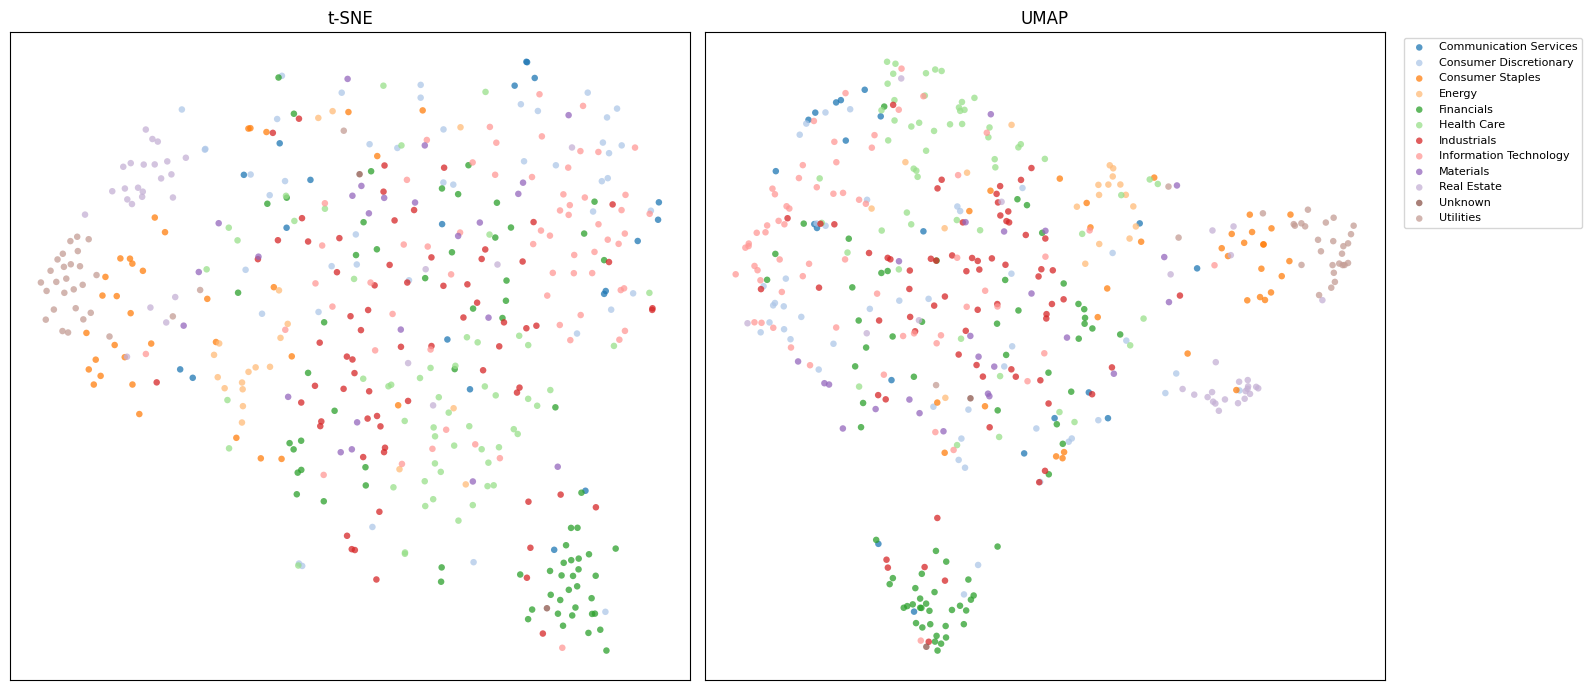

In [16]:
palette = plt.cm.tab20.colors
sec_list = sorted(sectors.unique())
col_map = {s: palette[i % len(palette)] for i, s in enumerate(sec_list)}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, proj, title in [(axes[0], tsne, "t-SNE"), (axes[1], umap_proj, "UMAP")]:
    for s in sec_list:
        m = sectors.values == s
        ax.scatter(proj[m, 0], proj[m, 1], s=22, c=[col_map[s]], label=s, alpha=0.75, edgecolor="none")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## Three numbers that check the same thing more rigorously

The picture is suggestive; these three numbers make it precise:
- **Industry-separation score** (measured on the full 12-number fingerprints, not the flattened picture). Runs −1 to +1: positive means stocks sit closer to same-industry peers than to others; near zero means the fingerprints barely track industry; negative means they are actively jumbled. For daily stock moves we expect something mildly positive — industry matters, but behaviour also cuts across it. (Its technical name is the *silhouette*.)
- **Is the map faithful? (trustworthiness)** — of the near-neighbours a stock has *in the picture*, what share are also its true near-neighbours in the full 12 numbers? High means the picture is not inventing closeness that is not really there.
- **Is the map complete? (continuity)** — of a stock's true near-neighbours in the full 12 numbers, what share are still near it *in the picture*? High means the picture is not dropping real closeness.

We use a neighbourhood of 15 — about the size of a plausible group of pair candidates.

In [17]:
known = sectors.values != "Unknown"
sil = silhouette_score(Z_asset[known], sectors.values[known])

k = 15
t_tsne = trustworthiness(Z_asset, tsne,      n_neighbors=k)
c_tsne = trustworthiness(tsne,    Z_asset,   n_neighbors=k)
t_umap = trustworthiness(Z_asset, umap_proj, n_neighbors=k)
c_umap = trustworthiness(umap_proj, Z_asset, n_neighbors=k)

print(f"Silhouette by sector (12-D):         {sil:+.3f}")
print(f"t-SNE  trustworthiness / continuity: {t_tsne:.3f} / {c_tsne:.3f}")
print(f"UMAP   trustworthiness / continuity: {t_umap:.3f} / {c_umap:.3f}")

Silhouette by sector (12-D):         +0.010
t-SNE  trustworthiness / continuity: 0.921 / 0.887
UMAP   trustworthiness / continuity: 0.913 / 0.904


## The "obvious pairs" test

A handful of textbook look-alikes — Coke & Pepsi, JPMorgan & Bank of America, Visa & Mastercard, and so on. If the fingerprint space is meaningful, each of these should land near the top of its partner's nearest-neighbour list (out of 461 other stocks). We report the rank: 1 means closest possible. Ranks in the low tens are strong evidence the space captures real behaviour; ranks in the hundreds would mean it is too noisy to rely on.

In [18]:
D = squareform(pdist(Z_asset))                      # (462, 462)
rank = D.argsort(axis=1).argsort(axis=1)            # 0 = self, 1 = nearest, ...

probes = [("KO","PEP"), ("JPM","BAC"), ("MA","V"),
          ("XOM","CVX"), ("HD","LOW"), ("GOOGL","META"),
          ("UPS","FDX"), ("WMT","TGT")]
for a, b in probes:
    if a in tickers and b in tickers:
        i, j = tickers.index(a), tickers.index(b)
        print(f"{a:>5} - {b:<5}  rank {rank[i,j]:>3} / {len(tickers)-1}   latent-dist {D[i,j]:.3f}")
    else:
        print(f"{a}-{b}: missing from universe")

   KO - PEP    rank  10 / 461   latent-dist 0.308
  JPM - BAC    rank   2 / 461   latent-dist 0.098
   MA - V      rank   4 / 461   latent-dist 0.193
  XOM - CVX    rank   3 / 461   latent-dist 0.312
   HD - LOW    rank  58 / 461   latent-dist 0.294
GOOGL - META   rank  21 / 461   latent-dist 0.419
  UPS - FDX    rank  31 / 461   latent-dist 0.297
  WMT - TGT    rank  13 / 461   latent-dist 0.301


**The same test as a picture.** Each bar is one textbook pair's rank in its partner's
nearest-neighbour list (1 = the single closest stock of 461). The red dashed line marks the top 5% —
every probe pair inside it means the fingerprint space is putting famous economic relatives next to
each other without ever being told about them.

In [ ]:
found = [(a, b) for a, b in probes if a in tickers and b in tickers]
labels = [f'{a}-{b}' for a, b in found]
ranks = [rank[tickers.index(a), tickers.index(b)] for a, b in found]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(labels[::-1], ranks[::-1], color='steelblue')
ax.axvline(23, color='r', ls='--', lw=0.8, label='top 5% (rank 23)')
ax.set_xlabel(f'nearest-neighbour rank (1 = closest of {len(tickers) - 1})'); ax.legend()
ax.set_title("Textbook pairs land near the top of each other's neighbour lists")
plt.tight_layout(); plt.show()

## The strictest test: does "close fingerprints" really mean "moves together"?

This is the make-or-break check. Across all ~106,000 possible pairs of stocks we compare two things: how *close* their fingerprints are, and how *together their daily moves actually were* over 2015–2019. If close fingerprints really do mean co-movement, these two should line up — and then the grouping in Phase 3 will surface genuine co-movers.

We summarise how well they line up with a single agreement score (a rank-based correlation). To be sure it isn't luck, we then **shuffle the stock labels 1,000 times** and see what agreement score pure chance produces; the *p-value* is how often chance beats our real score.

**Pass mark:** a clearly positive agreement score and a p-value well below 0.05. We do not expect a huge score — daily stock moves are very noisy — just a real, repeatable link in the right direction.

In [19]:
lr = pd.read_parquet("data/processed/log_returns_clean.parquet")[tickers].loc[:"2019-12-31"]
corr = lr.corr().values                                # (462, 462), 2015-2019 only

iu = np.triu_indices(len(tickers), k=1)
d_vec = D[iu]
c_vec = corr[iu]

rho, _ = spearmanr(-d_vec, c_vec)

N_PERM = 1000
rng = np.random.default_rng(42)
null = np.empty(N_PERM)
for i in range(N_PERM):
    perm = rng.permutation(len(tickers))
    D_p = D[np.ix_(perm, perm)]
    null[i] = spearmanr(-D_p[iu], c_vec).statistic

p = (np.sum(null >= rho) + 1) / (N_PERM + 1)
print(f"Spearman rho (-latent dist  vs  return corr) : {rho:+.3f}")
print(f"Null mean +/- std                            : {null.mean():+.3f} +/- {null.std():.3f}")
print(f"Permutation p-value ({N_PERM} shuffles)        : {p:.4f}")

Spearman rho (-latent dist  vs  return corr) : +0.479
Null mean +/- std                            : -0.001 +/- 0.024
Permutation p-value (1000 shuffles)        : 0.0010


**The make-or-break test as two pictures.**

- **Left — every pair at once.** Each hexagon holds many of the ~107,000 stock pairs: fingerprint
  distance across (left–right), actual 2015–2019 return correlation up-down. The cloud sloping
  **down and to the right** is the whole story — the closer two fingerprints, the more the stocks
  actually moved together.
- **Right — is it luck?** The grey bell is what the agreement score looks like when the stock labels
  are shuffled 1,000 times (pure chance). The red line is our real score. The distance between them
  *is* the p-value: the real structure sits far outside anything chance produced.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
hb = ax[0].hexbin(d_vec, c_vec, gridsize=60, cmap='Blues', mincnt=1)
ax[0].set_xlabel('fingerprint distance'); ax[0].set_ylabel('return correlation 2015-2019')
ax[0].set_title(f'All {len(d_vec):,} pairs: closer fingerprints = higher co-movement')
fig.colorbar(hb, ax=ax[0], label='pairs per hexagon')
ax[1].hist(null, bins=40, color='grey', alpha=0.8, label='chance (1,000 label shuffles)')
ax[1].axvline(rho, color='r', lw=2, label=f'observed rho = {rho:+.3f}')
ax[1].set_xlabel('Spearman rho'); ax[1].legend()
ax[1].set_title(f'Permutation test (p = {p:.4f})')
plt.tight_layout(); plt.show()

## Two quick health checks on the fingerprints

- **Any blank numbers?** If one of the 12 fingerprint numbers is almost the same for every stock, it carries no information and is just dead weight. We flag any number whose spread is far below the others. (Averaging many windows naturally shrinks these spreads, so we judge each number *relative* to the rest rather than against a fixed cutoff.)
- **Is the space too spread out?** If every stock is roughly as far from its nearest neighbour as it is from everyone else, then "nearest" barely means anything. We want a clear gap between "distance to nearest neighbour" and "distance to a typical stock".

In [20]:
dim_std = Z_asset.std(axis=0)
thresh = 0.3 * np.median(dim_std)
dead = (dim_std < thresh).sum()
print(f"Per-dim std of asset profiles: {np.round(dim_std, 3)}")
print(f"Near-dead dimensions (std < 0.3 x median = {thresh:.3f}): {dead} / {Z_asset.shape[1]}")

np.fill_diagonal(D, np.inf)
nn_dist = D.min(axis=1).mean()
np.fill_diagonal(D, 0.0)
all_dist = pdist(Z_asset).mean()
print(f"Mean nearest-neighbour distance: {nn_dist:.3f}")
print(f"Mean all-pairs distance        : {all_dist:.3f}")
print(f"Ratio (NN / all)               : {nn_dist/all_dist:.3f}   (lower = better separated)")

Per-dim std of asset profiles: [0.096 0.148 0.13  0.179 0.142 0.118 0.011 0.108 0.015 0.107 0.12  0.069]
Near-dead dimensions (std < 0.3 x median = 0.034): 2 / 12
Mean nearest-neighbour distance: 0.198
Mean all-pairs distance        : 0.538
Ratio (NN / all)               : 0.368   (lower = better separated)


**The blank fingerprint numbers, visualised.** One bar per fingerprint number: how much it varies
across the 462 stocks. Two bars (red) sit far below the dashed threshold — those numbers say almost
the same thing for every stock, so they carry no information and are excluded from the Phase 3
grouping. This is the standard VAE failure called *posterior collapse*, caught by measurement rather
than assumption.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(1, len(dim_std) + 1),  dim_std,
       color=['indianred' if s < thresh else 'steelblue' for s in dim_std])
ax.axhline(thresh, color='k', ls='--', lw=0.8, label=f'dead threshold ({thresh:.3f})')
ax.set_xlabel('fingerprint number'); ax.set_ylabel('spread across assets'); ax.legend()
ax.set_title('Two of twelve fingerprint numbers carry no information (posterior collapse)')
plt.tight_layout(); plt.show()

## Save artefacts for Phase 3

Three files the clustering step will reuse: the per-asset fingerprint profiles (input to HDBSCAN), the sector labels (colouring and cluster-composition reports), and the 2-D projections (for the final dissertation figures).

In [21]:
np.save("data/model_input/latent_profiles.npy", Z_asset)
sectors.to_csv("data/model_input/sectors.csv")
pd.DataFrame(
    {"tsne_x": tsne[:, 0], "tsne_y": tsne[:, 1],
     "umap_x": umap_proj[:, 0], "umap_y": umap_proj[:, 1],
     "sector": sectors.values},
    index=tickers,
).to_csv("data/model_input/latent_projections.csv")
print("Saved: latent_profiles.npy, sectors.csv, latent_projections.csv")

Saved: latent_profiles.npy, sectors.csv, latent_projections.csv
